# Notebook RMSE maps 


This notebook computes the temporally averaged Root Mean Square Error (RMSE) maps between reconstructed fields and the reference fields for all configurations, within the OSSE over the Hawaii region.

The resulting metrics are averaged over the whole time window, and are used in the Figures **04** and **08** presented in the manuscript.

In [ ]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd

import xskillscore

from pyinterp import fill, Axis, TemporalAxis, Grid3D, Grid2D
n_workers = 10

from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker 

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
path_data = "../.." # Change path according to where data are saved

## Importing data

QG reconstruction 

In [ ]:
ds_QG = xr.open_mfdataset(f"{path_data}/data/mapping_outputs/config_QG/*.nc")
ssh_bm_QG = ds_QG.ssh_bm.load()
ssh_bm_QG = ssh_bm_QG.rename({"lon":"longitude","lat":"latitude"})

Opening went wrong, OSError occured. Trying again ...


QG/SW reconstruction 

In [ ]:
ds_QGSW = xr.open_mfdataset(f"{path_data}/data/mapping_outputs/config_QGSW/*.nc")
# - BALANCED MOTIONS BM - #
ssh_bm_QGSW = ds_QGSW.ssh_bm.load()
ssh_bm_QGSW = ssh_bm_QGSW.rename({"lon":"longitude","lat":"latitude"})
# - INTERNAL TIDE IT - #
ssh_it_QGSW = ds_QGSW.ssh_it.load()
ssh_it_QGSW = ssh_it_QGSW.rename({"lon":"longitude","lat":"latitude"})

QG/SW reconstruction with no time control for IT

In [ ]:
ds_QGSW_notime = xr.open_mfdataset(f"{path_data}/data/mapping_outputs/config_QGSW_notime/*.nc")
# - BALANCED MOTIONS BM - #
ssh_bm_QGSW_notime = ds_QGSW_notime.ssh_bm.load()
ssh_bm_QGSW_notime = ssh_bm_QGSW_notime.rename({"lon":"longitude","lat":"latitude"})
# - INTERNAL TIDE IT - #
ssh_it_QGSW_notime = ds_QGSW_notime.ssh_it.load()
ssh_it_QGSW_notime = ssh_it_QGSW_notime.rename({"lon":"longitude","lat":"latitude"})

Reference dataset 

In [ ]:
%run ./functions_interp.ipynb

In [ ]:
ds_truth = xr.open_mfdataset(f"{path_data}/data/OSSE/ref/*.nc")
ds_truth = ds_truth.sel(longitude=slice(ssh_bm_QG.longitude[0],ssh_bm_QG.longitude[-1]),
                        latitude=slice(ssh_bm_QG.latitude[0],ssh_bm_QG.latitude[-1]),
                        time = slice(ssh_bm_QG.time[0],ssh_bm_QG.time[-1]),drop=True)
ssh_bm_truth = ds_truth.ssh_bm.load()
ssh_it_12h_truth = ds_truth.ssh_it_12h.load()
ssh_it_truth = ds_truth.ssh_it.load()
ssh_tot_truth = ds_truth.ssh.load()

In [6]:
ssh_bm_truth = fill_nan(ssh_bm_truth)
ssh_it_truth = fill_nan(ssh_it_truth)
ssh_tot_truth = fill_nan(ssh_tot_truth)

## Common parameters 

Starting timestep and ending timestep for computing RMSE 

In [7]:
i_start = 10*24 # Starting timestep 
i_end = -5*24 # Ending timestep 

## Computing statistical analysis

Maps of RMSE 

In [58]:
## - SSH BM - ##
rmse_bm_QG_map = xskillscore.rmse(ssh_bm_QG[i_start:i_end,:,:], ssh_bm_truth[i_start:i_end,:,:], dim=['time'], skipna=True).compute()
rmse_bm_QGSW_map = xskillscore.rmse(ssh_bm_QGSW[i_start:i_end,:,:], ssh_bm_truth[i_start:i_end,:,:], dim=['time'], skipna=True).compute()
rmse_bm_QGSW_notime_map = xskillscore.rmse(ssh_bm_QGSW_notime[i_start:i_end,:,:], ssh_bm_truth[i_start:i_end,:,:], dim=['time'], skipna=True).compute()
## - SSH IT - ##
rmse_it_QGSW_map = xskillscore.rmse(ssh_it_QGSW[i_start:i_end,:,:], ssh_it_truth[i_start:i_end,:,:], dim=['time'], skipna=True).compute()
rmse_it_QGSW_notime_map = xskillscore.rmse(ssh_it_QGSW_notime[i_start:,:,:], ssh_it_truth[i_start:,:,:], dim=['time'], skipna=True).compute()


Uploading SWOT track coordinates to diplay them on the maps 

In [ ]:
swot_track = xr.open_dataset(f"{path_data}/OSSE/obs/dc_obs_swot/SSH_SWOT_2012-06-22.nc")
mask_swot = (swot_track.longitude>ssh_bm_QG.longitude.min())*(swot_track.longitude<ssh_bm_QG.longitude.max())*\
    (swot_track.latitude>ssh_bm_QG.latitude.min())*(swot_track.latitude<ssh_bm_QG.latitude.max())
swot_track = swot_track.where(mask_swot,drop=True)

Uploading bathymetry to highlight the IT generation zone 

In [ ]:
bathy = xr.open_dataset("../mapping/aux/Bathymetry_hawai.nc")
bathy = bathy.assign_coords(lon=((bathy.lon % 360)))
bathy = bathy.sel(lon = slice(ssh_bm_QG.longitude.min(),ssh_bm_QG.longitude.max()),lat = slice(ssh_bm_QG.latitude.min(),ssh_bm_QG.latitude.max()))

## Figure **04**

In [19]:
lon_min = ssh_bm_QGSW.longitude.min().values
lon_max = ssh_bm_QGSW.longitude.max().values
lat_min = ssh_bm_QGSW.latitude.min().values
lat_max = ssh_bm_QGSW.latitude.max().values

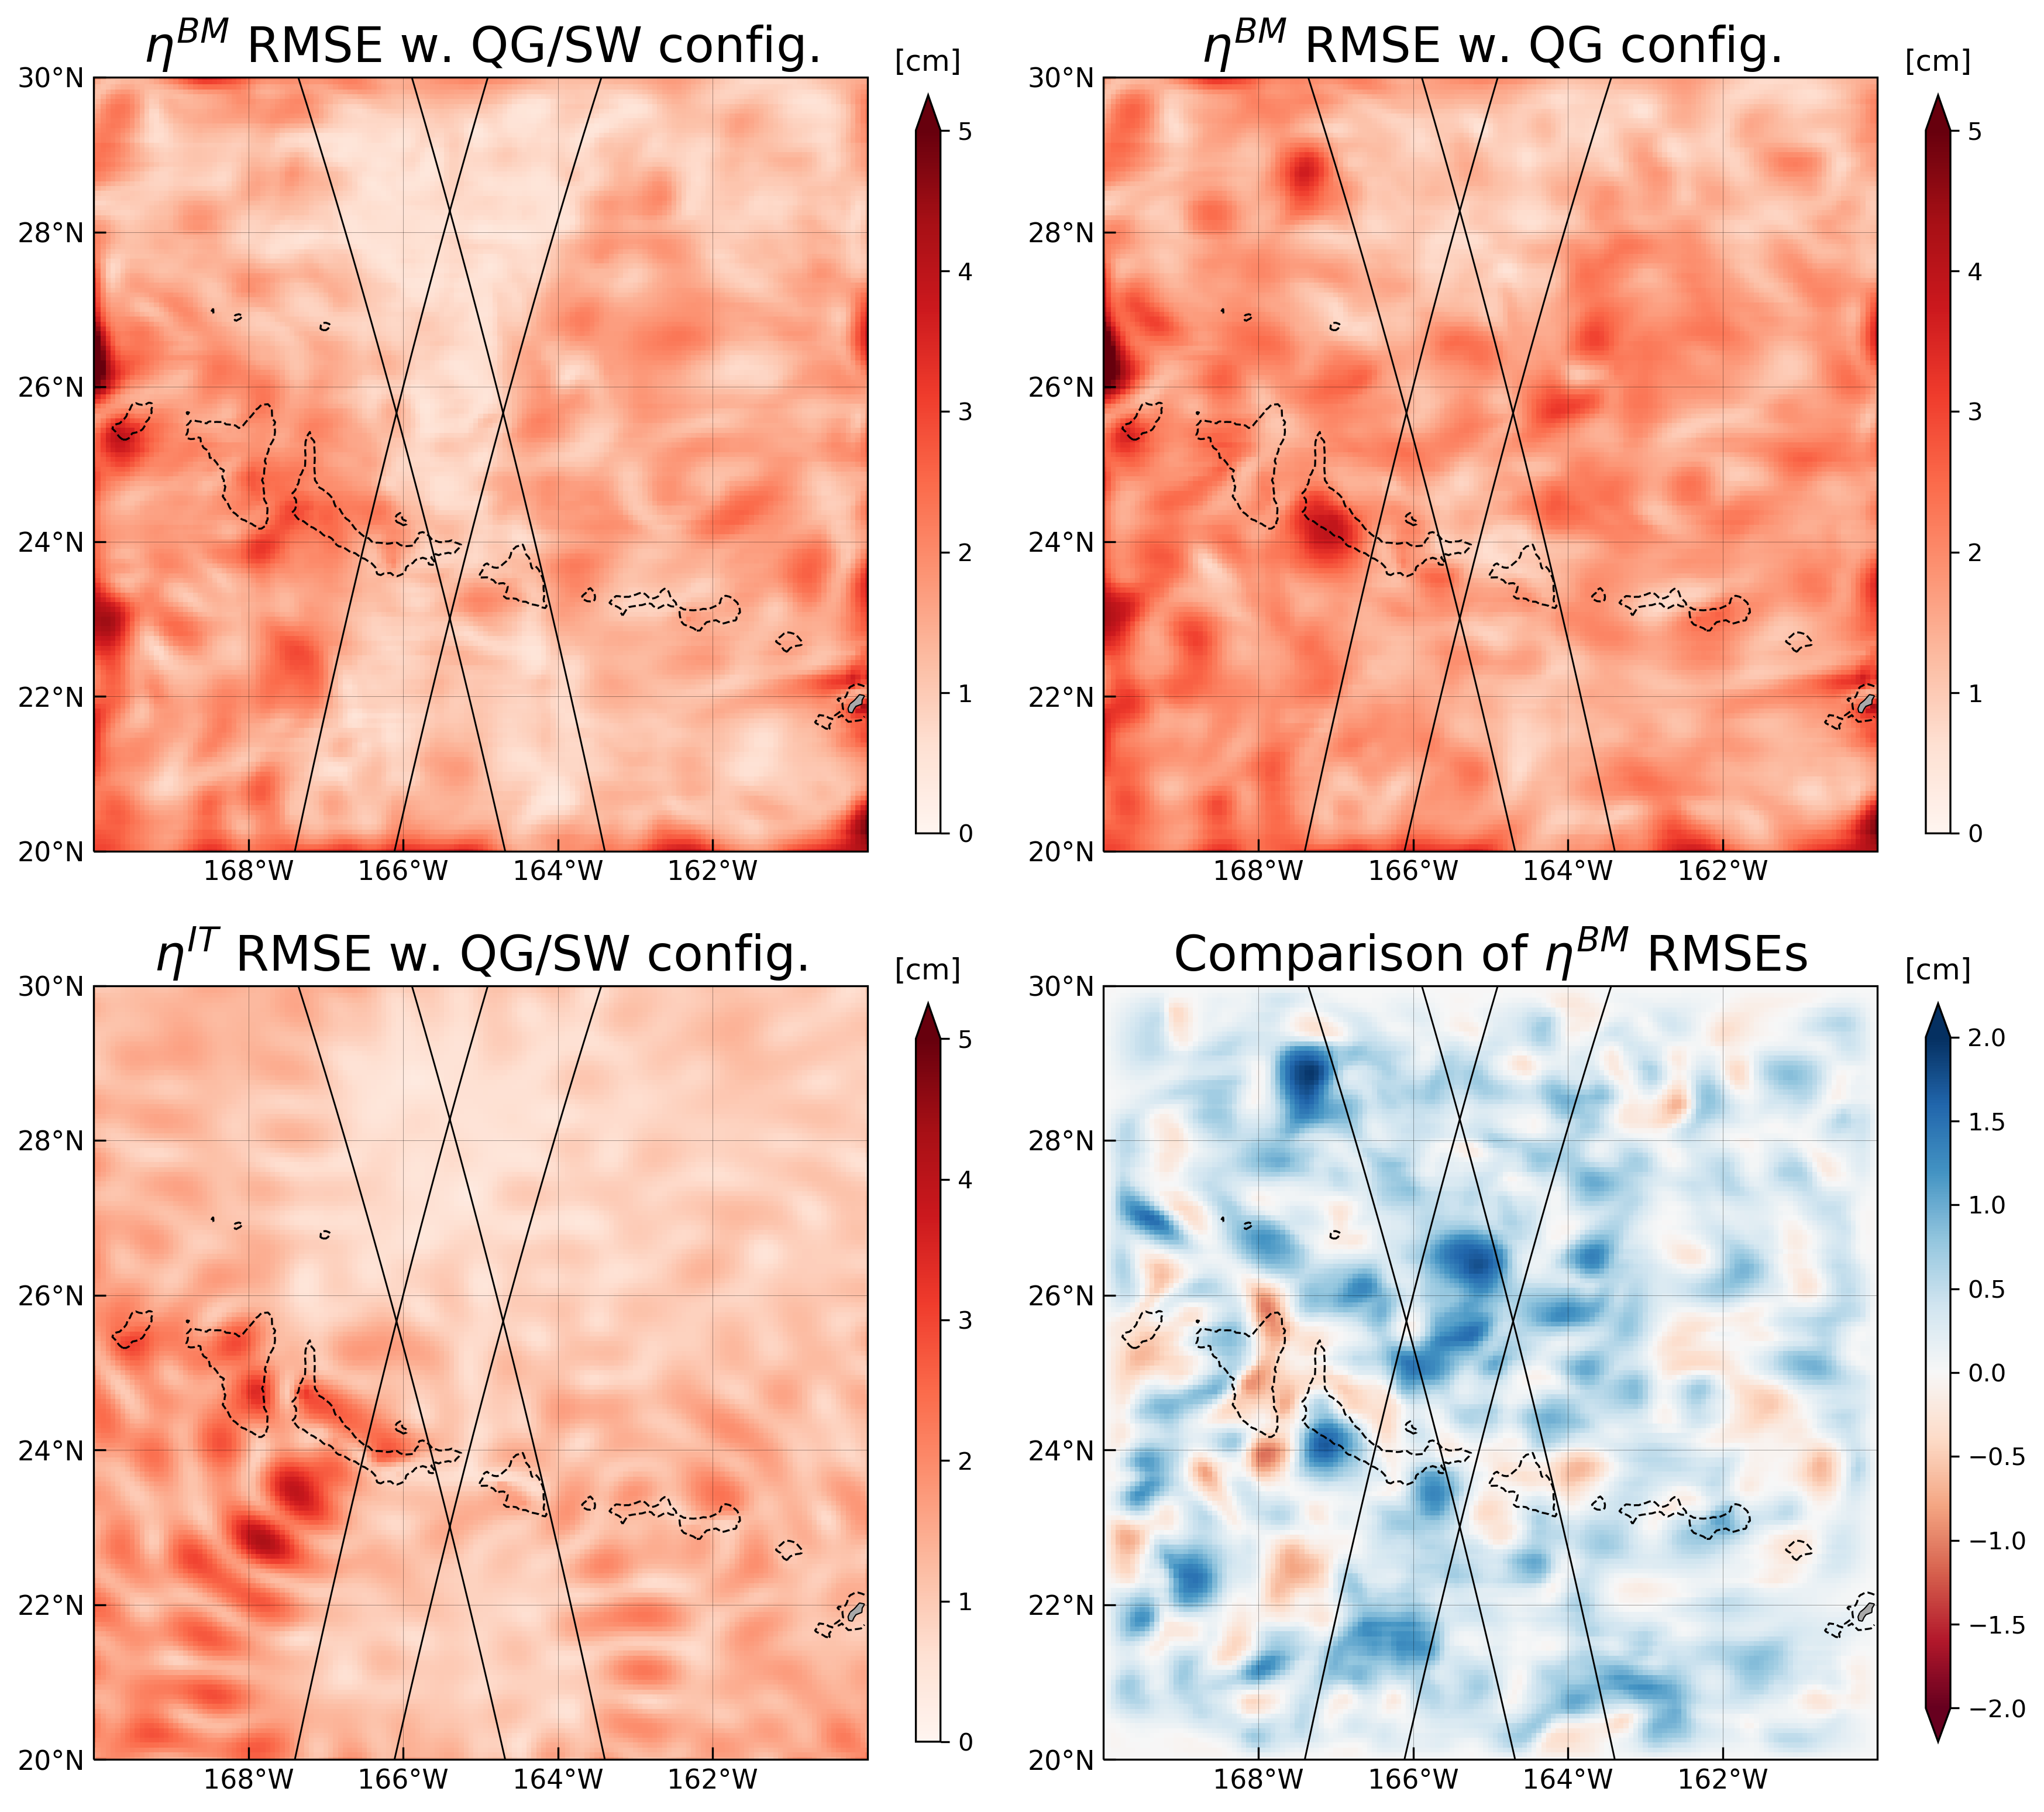

In [ ]:
proj = ccrs.PlateCarree()

v_min = 0;v_max=100*0.05
v_ex = 100*0.02

fig, ax = plt.subplots(2,2,figsize=(12,10.5),dpi=300,subplot_kw={"projection": proj})


### RMSE BM QG/SW ###

_plt_rmse_bm_QGSW = ax[0,0].pcolormesh(rmse_bm_QGSW_map.longitude,rmse_bm_QGSW_map.latitude,100*rmse_bm_QGSW_map,
                                cmap='Reds',vmin=v_min,vmax=v_max,transform=proj)

ax[0,0].set_title(r"$\eta^{BM}$ RMSE w. QG/SW config.", fontsize=20)

cbar_rmse_bm_QGSW = fig.colorbar(_plt_rmse_bm_QGSW,ax=ax[0,0],shrink=0.88,extend='max',aspect=30)
cbar_rmse_bm_QGSW.ax.set_title("[cm]", fontsize=12, pad=10)


### RMSE BM QG ###

_plt_rmse_bm_QG = ax[0,1].pcolormesh(rmse_bm_QG_map.longitude,rmse_bm_QG_map.latitude,100*rmse_bm_QG_map,
                                     cmap='Reds',vmin=v_min,vmax=v_max,transform=proj)

ax[0,1].set_title(r"$\eta^{BM}$ RMSE w. QG config.", fontsize=20)

cbar_rmse_bm_QG = fig.colorbar(_plt_rmse_bm_QG,ax=ax[0,1],shrink=0.88,extend='max',aspect=30)
cbar_rmse_bm_QG.ax.set_title("[cm]", fontsize=12, pad=10)

### RMSE IT QG/SW ###

_plt_rmse_it_QGSW = ax[1,0].pcolormesh(rmse_it_QGSW_map.longitude,rmse_it_QGSW_map.latitude,100*rmse_it_QGSW_map,
                                cmap='Reds',vmin=v_min,vmax=v_max,transform=proj)

ax[1,0].set_title(r"$\eta^{IT}$ RMSE w. QG/SW config.", fontsize=20)

cbar_rmse_it_QGSW = fig.colorbar(_plt_rmse_it_QGSW,ax=ax[1,0],shrink=0.88,extend='max',aspect=30)
cbar_rmse_it_QGSW.ax.set_title("[cm]", fontsize=12, pad=10)

### RMSE BM DIFF ###

_plt_rmse_bm_diff = ax[1,1].pcolormesh(rmse_bm_QGSW_map.longitude,rmse_bm_QGSW_map.latitude,100*(rmse_bm_QG_map-rmse_bm_QGSW_map),
                                       cmap='RdBu',vmin=-v_ex,vmax=v_ex,transform=proj)

ax[1,1].set_title(r"Comparison of $\eta^{BM}$ RMSEs", fontsize=20)

cbar_rmse_bm_diff = fig.colorbar(_plt_rmse_bm_diff,ax=ax[1,1],shrink=0.88,extend='both',aspect=30)
cbar_rmse_bm_diff.ax.set_title("[cm]", fontsize=12, pad=10)

### MAP FEATURES ###

for i,(_ax,_plt) in enumerate(zip(ax.flatten(),[_plt_rmse_bm_QGSW,_plt_rmse_bm_QG,_plt_rmse_it_QGSW,_plt_rmse_bm_diff])) : 
    _ax.plot(swot_track.longitude[:,4],swot_track.latitude[:,4],c='black',linewidth=0.7,transform=proj)
    _ax.plot(swot_track.longitude[:,-4],swot_track.latitude[:,-4],c='black',linewidth=0.7,transform=proj)
    _ax.set_ylim(ssh_bm_QG.latitude.min(),ssh_bm_QG.latitude.max())
    # _ax.set_aspect("equal")
    
    _ax.contour(bathy.lon[::10],bathy.lat[::10],bathy.elevation[::10,::10].values,levels=[-1500],
                colors='black', linewidths = 0.8,linestyles="dashed",transform=proj)


lon_ticks = np.arange(-168, -160, 2)
lat_ticks = np.arange(lat_min, lat_max+1, 2)

for i,_ax in enumerate(ax.flatten()):

    _ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    _ax.coastlines(resolution='50m', color='black', linewidth=1)

    _ax.add_feature(cfeature.LAND.with_scale('50m'),facecolor='darkgray',zorder=3)

    # ticks
    _ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    _ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())

    _ax.xaxis.set_major_formatter(LongitudeFormatter())
    _ax.yaxis.set_major_formatter(LatitudeFormatter())

    _ax.tick_params(labelsize=11)

    _ax.tick_params(axis='both',which='major',direction='in',length=5,width=0.8,labelsize=11)

    gl = _ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=False,linewidth=0.2,color='black',alpha=0.4,linestyle='-')

    gl.xlocator = mticker.FixedLocator(lon_ticks)
    gl.ylocator = mticker.FixedLocator(lat_ticks)

fig.tight_layout()


## Figure **08**

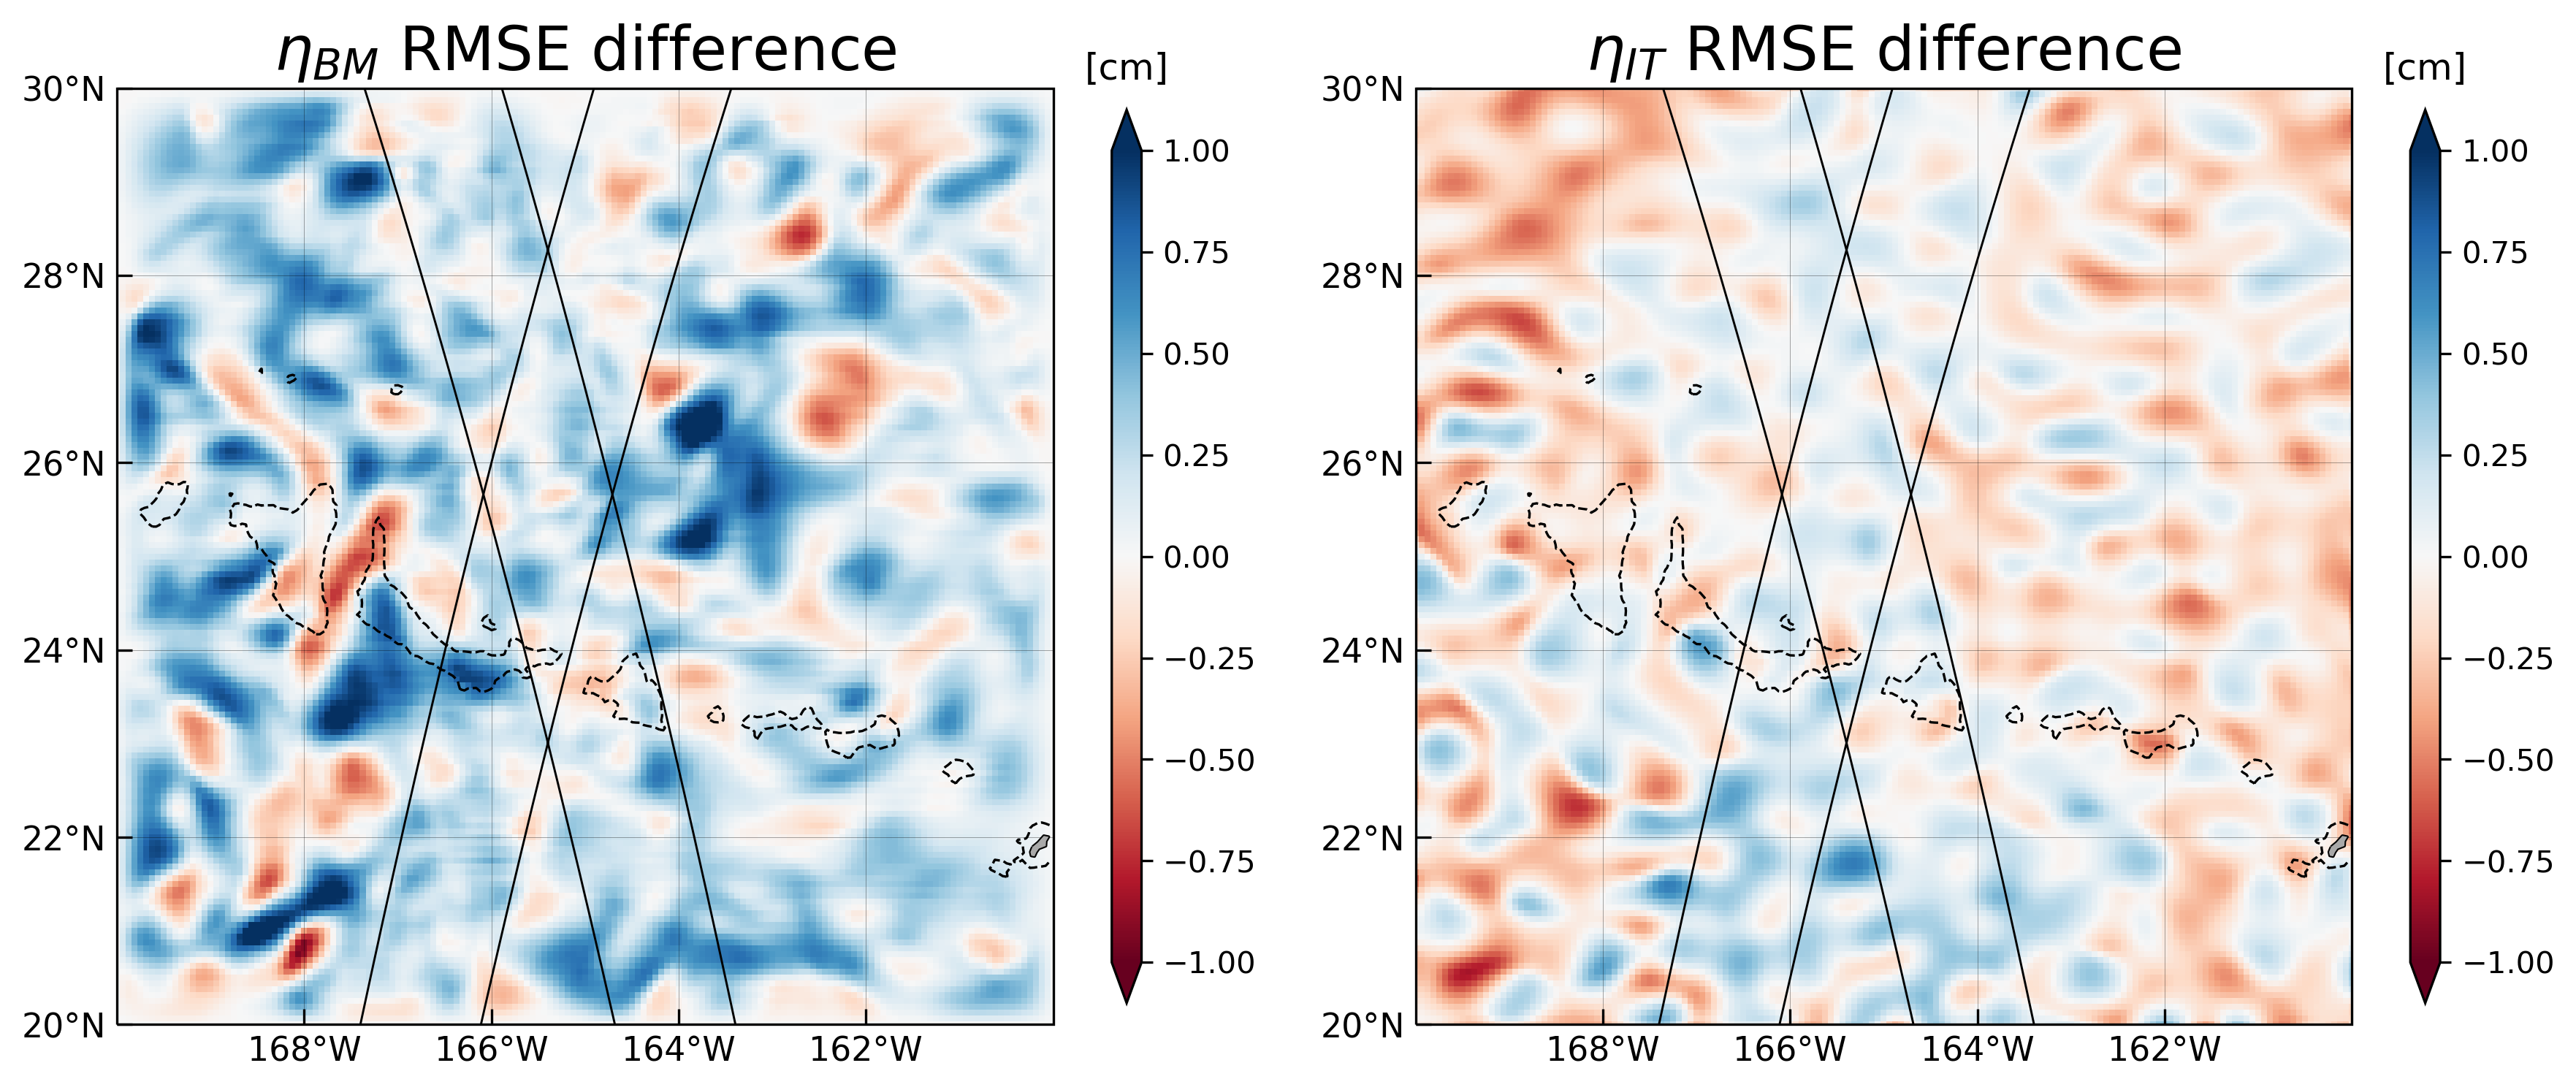

In [ ]:
proj = ccrs.PlateCarree()

v_min = 0;v_max=100*0.05
v_ex = 100*0.01

fig, ax = plt.subplots(1,2,figsize=(12,5),dpi=300,subplot_kw={"projection": proj})

### RMSE BM QG/SW ###

_plt_rmse_bm_QGSW = ax[0].pcolormesh(rmse_bm_QGSW_map.longitude,rmse_bm_QGSW_map.latitude,100*(rmse_bm_QGSW_notime_map-rmse_bm_QGSW_map),
                                cmap='RdBu',vmin=-v_ex,vmax=v_ex,transform=proj)

ax[0].set_title(r"$\eta_{BM}$ RMSE difference", fontsize=20)

cbar_rmse_bm_QGSW = fig.colorbar(_plt_rmse_bm_QGSW,ax=ax[0],shrink=0.88,extend='both',aspect=30)
cbar_rmse_bm_QGSW.ax.set_title("[cm]", fontsize=12, pad=10)


### RMSE BM QG ###

_plt_rmse_bm_QG = ax[1].pcolormesh(rmse_it_QGSW_map.longitude,rmse_it_QGSW_map.latitude,100*(rmse_it_QGSW_notime_map-rmse_it_QGSW_map),
                                     cmap='RdBu',vmin=-v_ex,vmax=v_ex,transform=proj)

ax[1].set_title(r"$\eta_{IT}$ RMSE difference", fontsize=20)

cbar_rmse_bm_QG = fig.colorbar(_plt_rmse_bm_QG,ax=ax[1],shrink=0.88,extend='both',aspect=30)
cbar_rmse_bm_QG.ax.set_title("[cm]", fontsize=12, pad=10)

### MAP FEATURES ###

for i,(_ax,_plt) in enumerate(zip(ax.flatten(),[_plt_rmse_bm_QGSW,_plt_rmse_bm_QG])) : 
    _ax.plot(swot_track.longitude[:,4],swot_track.latitude[:,4],c='black',linewidth=0.7,transform=proj)
    _ax.plot(swot_track.longitude[:,-4],swot_track.latitude[:,-4],c='black',linewidth=0.7,transform=proj)
    _ax.set_ylim(ssh_bm_QG.latitude.min(),ssh_bm_QG.latitude.max())
    # _ax.set_aspect("equal")
    
    _ax.contour(bathy.lon[::10],bathy.lat[::10],bathy.elevation[::10,::10].values,levels=[-1500],
                colors='black', linewidths = 0.8,linestyles="dashed",transform=proj)


lon_ticks = np.arange(-168, -160, 2)
lat_ticks = np.arange(lat_min, lat_max+1, 2)

for i,_ax in enumerate(ax.flatten()):

    _ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    _ax.coastlines(resolution='50m', color='black', linewidth=1)

    _ax.add_feature(cfeature.LAND.with_scale('50m'),facecolor='darkgray',zorder=3)

    # ticks
    _ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    _ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())

    _ax.xaxis.set_major_formatter(LongitudeFormatter())
    _ax.yaxis.set_major_formatter(LatitudeFormatter())

    _ax.tick_params(labelsize=11)

    _ax.tick_params(axis='both',which='major',direction='in',length=5,width=0.8,labelsize=11)

    gl = _ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=False,linewidth=0.2,color='black',alpha=0.4,linestyle='-')

    gl.xlocator = mticker.FixedLocator(lon_ticks)
    gl.ylocator = mticker.FixedLocator(lat_ticks)

fig.tight_layout()
